In [ ]:
import numpy as np

X_train = np.load('/content/drive/MyDrive/1. Natural Language Processsing/Khóa luận tốt nghiệp/Word2vec/English/training.npy')
y_train = np.load('/content/drive/MyDrive/1. Natural Language Processsing/Khóa luận tốt nghiệp/Word2vec/English/training_labels.npy')
X_test = np.load('/content/drive/MyDrive/1. Natural Language Processsing/Khóa luận tốt nghiệp/Word2vec/English/test.npy')
y_test = np.load('/content/drive/MyDrive/1. Natural Language Processsing/Khóa luận tốt nghiệp/Word2vec/English/test_labels.npy')
embedding_matrix = np.load('/content/drive/MyDrive/1. Natural Language Processsing/Khóa luận tốt nghiệp/Word2vec/English/embedding_matrix.npy')

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Bidirectional, Dense, Embedding, LSTM, Dropout, Conv1D, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping

vocab_size = 52145

# embedding = Embedding(vocab_size,
#                       output_dim=int(3e2),
#                       weights=[embedding_matrix],
#                       trainable=True)

# Variable-length int sequences.
input = tf.keras.Input(shape=(300,), dtype='int32')

# Embedding lookup.
token_embedding = tf.keras.layers.Embedding(vocab_size,
                      output_dim=int(3e2),
                      weights=[embedding_matrix],
                      trainable=True)
# Query embeddings of shape [batch_size, Tq, dimension].
query_embeddings = token_embedding(input)
# Value embeddings of shape [batch_size, Tv, dimension].
value_embeddings = token_embedding(input)

# CNN layer.
cnn_layer = Conv1D(filters=128,kernel_size=5,padding='same')(query_embeddings)
cnn_drop = Dropout(0.25)(cnn_layer)
BiLSTM_layer1 = Bidirectional(LSTM(128, return_sequences=True))(cnn_drop)
blstm_drop = Dropout(0.25)(BiLSTM_layer1)
BiLSTM_layer2 = Bidirectional(LSTM(128, return_sequences=True))(blstm_drop)
blstm2_drop = Dropout(0.25)(BiLSTM_layer2)

# query_seq_encoding = layer(query_embeddings)
# value_seq_encoding = layer(value_embeddings)

# Attention layer 1
query_value_attention_seq = tf.keras.layers.Attention()([blstm2_drop, blstm2_drop])

query_encoding = tf.keras.layers.GlobalAveragePooling1D()(blstm2_drop)

query_value_attention = tf.keras.layers.GlobalAveragePooling1D()(query_value_attention_seq)

input_layer = tf.keras.layers.Concatenate()([query_encoding, query_value_attention])

clf = Dense(128,activation="relu")(input_layer)
fc_drop = Dropout(0.25)(clf)
clf = Dense(1,activation="sigmoid")(fc_drop)

model = Model(input, clf)

model.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              metrics=['accuracy'])

model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 300)]                0         []                            
                                                                                                  
 embedding_1 (Embedding)     (None, 300, 300)             1564350   ['input_2[0][0]']             
                                                          0                                       
                                                                                                  
 conv1d_1 (Conv1D)           (None, 300, 128)             192128    ['embedding_1[0][0]']         
                                                                                                  
 dropout_3 (Dropout)         (None, 300, 128)             0         ['conv1d_1[0][0]']      

In [ ]:
callbacks = EarlyStopping(monitor='val_loss', min_delta=1e-3, patience=5)
history = model.fit(X_train, y_train,
                    batch_size=1024,
                    epochs=100,
                    verbose=1,
                    validation_split=0.1)


Epoch 1/100
22/22 [==============================] - 27s 938ms/step - loss: 0.6875 - accuracy: 0.5869 - val_loss: 0.7236 - val_accuracy: 0.0732
Epoch 2/100
22/22 [==============================] - 20s 901ms/step - loss: 0.6795 - accuracy: 0.5809 - val_loss: 0.7488 - val_accuracy: 0.0608
Epoch 3/100
22/22 [==============================] - 19s 864ms/step - loss: 0.6710 - accuracy: 0.5809 - val_loss: 0.7666 - val_accuracy: 0.0872
Epoch 4/100
22/22 [==============================] - 19s 878ms/step - loss: 0.6612 - accuracy: 0.5945 - val_loss: 0.7708 - val_accuracy: 0.1500
Epoch 5/100
22/22 [==============================] - 19s 877ms/step - loss: 0.6475 - accuracy: 0.6272 - val_loss: 0.7576 - val_accuracy: 0.2836
Epoch 6/100
22/22 [==============================] - 19s 859ms/step - loss: 0.6287 - accuracy: 0.6780 - val_loss: 0.7221 - val_accuracy: 0.4668
Epoch 7/100
22/22 [==============================] - 19s 860ms/step - loss: 0.6033 - accuracy: 0.7261 - val_loss: 0.6856 - val_accuracy:

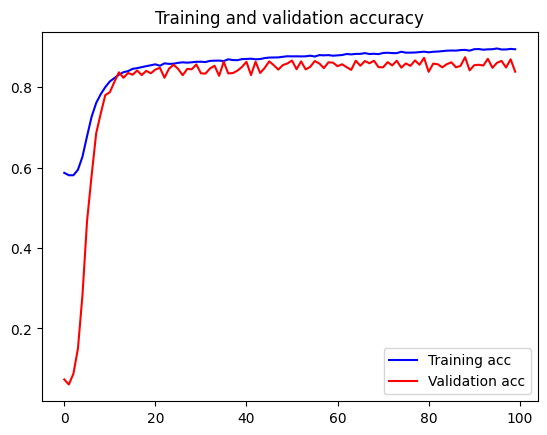

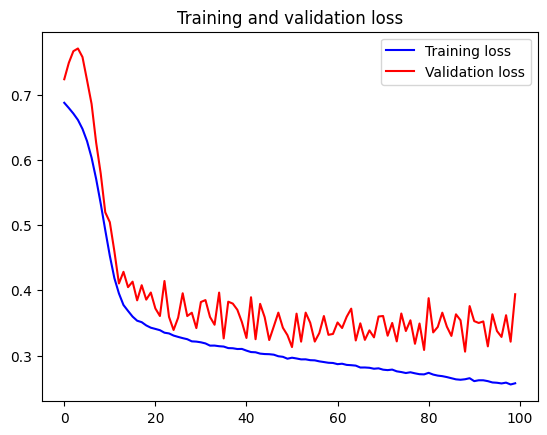

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [ ]:
score = model.evaluate(X_test, y_test, batch_size=1024)
print()
print("ACCURACY:",score[1])
print("LOSS:",score[0])

25/25 [==============================] - 7s 259ms/step - loss: 0.3049 - accuracy: 0.8758

ACCURACY: 0.8758350610733032
LOSS: 0.3049263060092926


In [ ]:
model.save('/content/drive/MyDrive/1. Natural Language Processsing/Khóa luận tốt nghiệp/Word2vec/English/model_CNN_BiLSTM_Att.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
